# <h3 align="center">Unnas Hussain</h3>

Data Modeling Activity

## Objective
Familiarize yourself with key data modeling concepts (classification, regression, and clustering) by analyzing a dataset and discussing how different modeling approaches apply.

---

## Instructions

### 1. Find a Dataset
Use the `kagglehub` library to download a dataset from Kaggle. Ensure that you have set up the library with your Kaggle API key. An example of how to do this is provided below:

In [86]:
import kagglehub as kh
# Install kagglehub if not already installed
# !pip install kagglehub


# Example: Downloading a dataset
# Replace 'dataset-owner/dataset-name' with the Kaggle dataset identifier
kh.dataset_download('sandibaressiegota/robot-kinematics-dataset', output_dir='datasets')

# Load the dataset
import pandas as pd
data = pd.read_csv("datasets/robot_inverse_kinematics_dataset.csv")

# Display the first few rows of the dataset
data.head()

# Basic dataset summary
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   q1      15000 non-null  float64
 1   q2      15000 non-null  float64
 2   q3      15000 non-null  float64
 3   q4      15000 non-null  float64
 4   q5      15000 non-null  float64
 5   q6      15000 non-null  float64
 6   x       15000 non-null  float64
 7   y       15000 non-null  float64
 8   z       15000 non-null  float64
dtypes: float64(9)
memory usage: 1.0 MB


,q1,q2,q3,q4,q5,q6,x,y,z
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.000855,-0.009156,1.572407,0.018612,-0.009395,3.143289,-0.005186,-0.000697,0.257294
std,1.655036,1.110602,0.201659,1.619865,1.211110,1.810345,0.102542,0.105618,0.112316
min,-2.880000,-1.920000,1.220000,-2.790000,-2.090000,0.000441,-0.290000,-0.298000,-0.020800
25%,-1.430000,-0.979250,1.400000,-1.380000,-1.060000,1.580000,-0.086900,-0.083700,0.165000
50%,0.006850,-0.010200,1.570000,0.038650,-0.021100,3.150000,-0.006940,-0.000201,0.256000
75%,1.420000,0.957000,1.750000,1.410000,1.040000,4.710000,0.075500,0.081900,0.343000
max,2.880000,1.920000,1.920000,2.790000,2.090000,6.280000,0.292000,0.297000,0.490000


### 2. Dataset Exploration
Answer the following questions about your dataset:
1. What types of features are present (numerical, categorical, etc.)?
2. Are there any missing values or data quality issues?
3. What potential problems can this dataset solve? Identify tasks for classification, regression, and clustering.

Add your answers in the markdown cell below.

---

### 3. Tasks

#### **Classification**
- Define a classification problem in the dataset (e.g., predicting if a customer will churn).
- Optionally, implement a simple logistic regression or decision tree model.
  
##### Overview
For this activity, I am using a dataset for a 6-DOF robotic arm. The data is random angular values for each joint (q1-6)  and then the resulting end effector position in 3 dimensions. For classification, I bin the z-axis position into high, mid, and low positions. This could be useful if you had obstacles without defined positions around the arm, but you knew in general they would be above or below certain heights.

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Classify modeled end effector's z-axis position into 'low, 'mid', or 'high'
data['z_zone'] = pd.cut(data['z'], bins=3, labels=['low', 'mid', 'high'])

# Features: joint angle inputs
# Target: z_zone outputs
X = data[['q1', 'q2', 'q3', 'q4', 'q5', 'q6']]
y = data["z_zone"]

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000) # accuracy was ~60%, data isnt linear
model.fit(X_train, y_train)

# Logistic regression underperforms here because the mapping from joint angles to position is nonlinear. A decision tree will do better

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred))
print("LR Classification Report:\n", classification_report(y_test, y_pred))

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred2 = dt_model.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred2))
print("LR Classification Report:\n", classification_report(y_test, y_pred2))

LR Accuracy: 0.5956666666666667
LR Classification Report:
               precision    recall  f1-score   support

        high       0.72      0.72      0.72       951
         low       0.27      0.09      0.13       607
         mid       0.57      0.73      0.64      1442

    accuracy                           0.60      3000
   macro avg       0.52      0.51      0.50      3000
weighted avg       0.55      0.60      0.56      3000

LR Accuracy: 0.8553333333333333
LR Classification Report:
               precision    recall  f1-score   support

        high       0.88      0.86      0.87       951
         low       0.83      0.85      0.84       607
         mid       0.85      0.85      0.85      1442

    accuracy                           0.86      3000
   macro avg       0.85      0.86      0.85      3000
weighted avg       0.86      0.86      0.86      3000



#### **Regression**
- Define a regression problem in the dataset (e.g., predicting house prices).
- Optionally, implement a simple linear regression model.

##### Overview
For regression, we can model the relationship between the joint angles and the end effector's position in the X-Axis. To be frank, this isnt' really a good fit for this data because when you're talking about serialized robotic arms, there are very well defined forward kinematics to find this relationship. And you can tell because a linear regression is not enough to get a good R^2 value. It was still an interesting exercise though.

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

# Replace 'target' with your target column name
X = data[['q1', 'q2', 'q3', 'q4', 'q5', 'q6']]
y = data['x']

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print("Linear Model: Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Linear Model: R-squared Score:", r2_score(y_test, y_pred))

# Same issue with linearity here, linear regression has a horrible R^2. A decision tree will do better
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred2 = dt_model.predict(X_test)
print("DT Model: Mean Squared Error:", mean_squared_error(y_test, y_pred2))
print("DT Model: R-squared Score:", r2_score(y_test, y_pred2))

Linear Model: Mean Squared Error: 0.010570559063663538
Linear Model: R-squared Score: 0.004333319245061529
DT Model: Mean Squared Error: 0.00408804034331924
DT Model: R-squared Score: 0.6149375321673616


#### **Clustering**
- Define how clustering might reveal patterns in your dataset.
- Optionally, implement a simple k-means clustering algorithm.

##### Overview
For clustering, we can cluster the end effector's overall workspace. The result is interesting, showing certain parts of the workspace (the end-dimensional space the end effector can reach) evenly clusters into 3 three-dimensional wedges. This means the robotic arm has good even reach within a sphere.

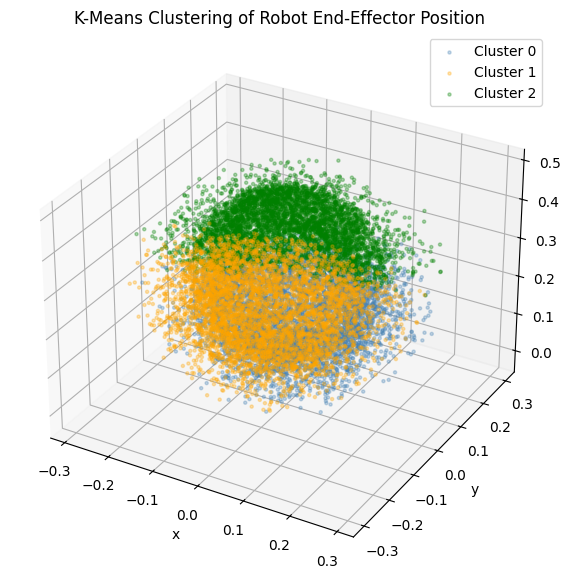

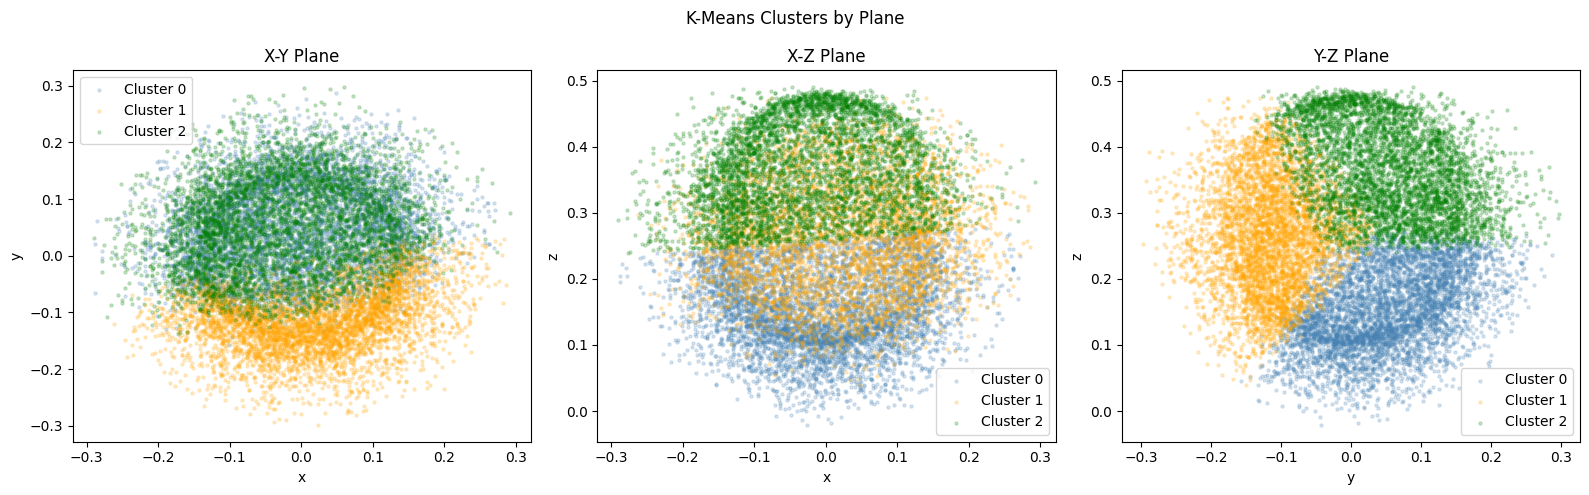

Centers
                x         y         z
Cluster                              
0       -0.007352  0.049604  0.151288
1        0.019436 -0.115689  0.265061
2       -0.026431  0.054721  0.365398


In [89]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use only numerical features for clustering
X = data[['x', 'y', 'z']]

# Train a k-means model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Add cluster labels to the dataset
data["Cluster"] = kmeans.labels_

# 3D scatter plot of the clusters
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = ['steelblue', 'orange', 'green']
for cluster in range(3):
  subset = data[data['Cluster'] == cluster]
  ax.scatter(subset['x'], subset['y'], subset['z'],
             s=5, alpha=0.3, color=colors[cluster], label=f'Cluster {cluster}')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('K-Means Clustering of Robot End-Effector Position')
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
  
colors = ['steelblue', 'orange', 'green']
planes = [('x', 'y'), ('x', 'z'), ('y', 'z')]

for ax, (feat1, feat2) in zip(axes, planes):
  for cluster in range(3):
      subset = data[data['Cluster'] == cluster]
      ax.scatter(subset[feat1], subset[feat2],
                 s=5, alpha=0.2, color=colors[cluster], label=f'Cluster {cluster}')
  ax.set_xlabel(feat1)
  ax.set_ylabel(feat2)
  ax.set_title(f'{feat1.upper()}-{feat2.upper()} Plane')
  ax.legend()

plt.suptitle('K-Means Clusters by Plane')
plt.tight_layout()
plt.show()

print("Centers")
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['x', 'y', 'z'])
centers.index.name = 'Cluster'
print(centers)

### 4. Reflection and Discussion

#### Supervised vs Unsupervised Learning
Supervised learning made sense for classification and regression because the dataset has clear inputs and outputs: joint angles go in, position comes out. We had a specific thing to predict, so labeled targets (z_zone, x) were natural (although, as discussed, non-linear).  Unsupervised clustering made sense when we didn't have a prediction goal and just wanted to explore the structure of the data. We didn't tell the model what to look for, and it found an interesting hidden trend. Its interesting that the clusters had distinct seperated Z-values, similar to the low, mid, and high-reaching regions, even though we never told the model anything about the clustering.

#### Challenges

The biggest challenge was that linear models  both performed poorly, R² near 0, accuracy around 60%! But the relationship between joint angles and position is trigonometric, not linear, that made sense. Switching to decision trees helped, but it would probably be best to stick with analytic kinematic models. For clustering, the challenge was interpretation. K-means just gives you numbered groups with no explanation of what they mean. Inspecting the centers of the clusters helped.

#### Conclusion

The Robot Kinematics Dataset contains 15,000 simulated positions of a robot arm with 6 joint angles (q1–q6) as inputs and the resulting x, y, z end-effector position as outputs. We classified which height "zones" the arm reaches, predicted the exact x position of a given joint configuration, and clustered the arm's reachable workspace into spatial wedge regions. The main takeaway from this activity is that model choice has to match the structure of the data. Linear models failed across both supervised tasks because the underlying math of robot kinematics is nonlinear Unsupervised clustering was interesting, it revealed structure in the output space without needing a target label, showing that the robot's reachable workspace naturally groups into spatial zones.